In [8]:
from pathlib import Path

import pandas as pd


DATA_DIR = Path("../data/raw/opensky/extracted")

files = sorted(DATA_DIR.glob("states_*.csv"))

print(f"Найдено файлов: {len(files)}")

for file in files:
    print(file)

Найдено файлов: 4
../data/raw/opensky/extracted/states_2022-05-30-07.csv
../data/raw/opensky/extracted/states_2022-05-30-09.csv
../data/raw/opensky/extracted/states_2022-05-30-19.csv
../data/raw/opensky/extracted/states_2022-06-27-09.csv


In [9]:
file = files[0]

df = pd.read_csv(file)

print(f"Файл: {file.name}")
print(f"Размер: {df.shape}")

display(df.head())

Файл: states_2022-05-30-07.csv
Размер: (1755078, 16)


,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact
0,1653894000,4ba8f6,47.523376,11.540794,175.497803,279.959333,0.00000,THY4JD,False,False,False,3205.0,9144.00,9166.86,1.653894e+09,1.653894e+09
1,1653894000,3c65d6,48.144882,11.244507,191.939325,254.771819,20.15744,DLH99E,False,False,False,6673.0,6804.66,6797.04,1.653894e+09,1.653894e+09
2,1653894000,39ceb1,48.303486,2.483705,199.060581,168.370632,13.98016,TVF73BW,False,False,False,7607.0,6073.14,6042.66,1.653894e+09,1.653894e+09
3,1653894000,440c33,49.750443,3.225210,227.996798,210.209908,0.32512,EJU69RM,False,False,False,2120.0,11277.60,11239.50,1.653894e+09,1.653894e+09
4,1653894000,502d6a,47.243454,3.708984,256.630739,129.305569,0.00000,EZY53UC,False,False,False,2703.0,10058.40,10081.26,1.653894e+09,1.653894e+09


In [10]:
df["datetime"] = pd.to_datetime(
    df["time"],
    unit="s",
    utc=True,
)

print("Начало:", df["datetime"].min())
print("Конец:", df["datetime"].max())

display(
    df[["time", "datetime", "icao24"]].head()
)

Начало: 2022-05-30 07:00:00+00:00
Конец: 2022-05-30 07:59:50+00:00


,time,datetime,icao24
0,1653894000,2022-05-30 07:00:00+00:00,4ba8f6
1,1653894000,2022-05-30 07:00:00+00:00,3c65d6
2,1653894000,2022-05-30 07:00:00+00:00,39ceb1
3,1653894000,2022-05-30 07:00:00+00:00,440c33
4,1653894000,2022-05-30 07:00:00+00:00,502d6a


In [13]:
trajectory = (
    df.dropna(
        subset=[
            "lat",
            "lon",
            "velocity",
            "heading",
            "vertrate",
            "baroaltitude",
        ]
    )
    .loc[df["onground"] == False]
    .sort_values(["icao24", "datetime"])
    .copy()
)

trajectory["dt_seconds"] = (
    trajectory.groupby("icao24")["datetime"]
    .diff()
    .dt.total_seconds()
)

gaps = trajectory["dt_seconds"].dropna()

print(f"Точек после фильтрации: {len(trajectory):,}")
print(f"Самолётов: {trajectory['icao24'].nunique():,}")

print("\nСтатистика интервалов:")
print(gaps.describe())

print("\nНаиболее частые интервалы:")
print(
    gaps.round()
    .value_counts()
    .sort_index()
    .head(10)
)

Точек после фильтрации: 1,432,565
Самолётов: 7,280

Статистика интервалов:
count    1.425285e+06
mean     1.043628e+01
std      2.505836e+01
min      1.000000e+01
25%      1.000000e+01
50%      1.000000e+01
75%      1.000000e+01
max      3.430000e+03
Name: dt_seconds, dtype: float64

Наиболее частые интервалы:
dt_seconds
10.0     1424144
20.0         126
30.0          32
40.0          31
50.0          24
60.0          35
70.0          26
80.0          25
90.0          19
100.0         14
Name: count, dtype: int64


In [14]:
trajectory["segment"] = (
    trajectory["dt_seconds"]
    .gt(20)
    .groupby(trajectory["icao24"])
    .cumsum()
)

segments = (
    trajectory
    .groupby(["icao24", "segment"])
    .size()
)

print(f"Всего сегментов: {len(segments):,}")

print("\nРазмер сегментов:")
print(segments.describe())

print("\nСегменты достаточной длины:")
print(f">= 60 точек  (10 минут): {(segments >= 60).sum():,}")
print(f">= 120 точек (20 минут): {(segments >= 120).sum():,}")
print(f">= 180 точек (30 минут): {(segments >= 180).sum():,}")
print(f">= 300 точек (50 минут): {(segments >= 300).sum():,}")

Всего сегментов: 8,295

Размер сегментов:
count    8295.000000
mean      172.702230
std       114.333376
min         1.000000
25%        73.000000
50%       154.000000
75%       267.000000
max       360.000000
dtype: float64

Сегменты достаточной длины:
>= 60 точек  (10 минут): 6,571
>= 120 точек (20 минут): 4,974
>= 180 точек (30 минут): 3,577
>= 300 точек (50 минут): 1,655


In [15]:
# Берём сегменты минимум на 30 минут
long_segments = segments[segments >= 180]

print(f"Сегментов >= 30 минут: {len(long_segments):,}")

# Самый длинный сегмент
icao24, segment_id = long_segments.idxmax()

print(f"\nСамолёт: {icao24}")
print(f"Сегмент: {segment_id}")
print(f"Точек: {long_segments.max()}")

Сегментов >= 30 минут: 3,577

Самолёт: 39ceb1
Сегмент: 0
Точек: 360


In [16]:
flight = trajectory[
    (trajectory["icao24"] == icao24)
    & (trajectory["segment"] == segment_id)
].copy()

print(f"Самолёт: {flight['icao24'].iloc[0]}")
print(f"Точек: {len(flight)}")
print(f"Время: {flight['datetime'].min()} → {flight['datetime'].max()}")

display(
    flight[
        [
            "datetime",
            "lat",
            "lon",
            "velocity",
            "heading",
            "vertrate",
            "baroaltitude",
        ]
    ].head(10)
)

Самолёт: 39ceb1
Точек: 360
Время: 2022-05-30 07:00:00+00:00 → 2022-05-30 07:59:50+00:00


,datetime,lat,lon,velocity,heading,vertrate,baroaltitude
2,2022-05-30 07:00:00+00:00,48.303486,2.483705,199.060581,168.370632,13.98016,6073.14
3019,2022-05-30 07:00:10+00:00,48.284167,2.489704,200.172269,168.285769,13.65504,6225.54
6416,2022-05-30 07:00:20+00:00,48.266373,2.495235,201.284392,168.201845,12.67968,6362.70
10645,2022-05-30 07:00:30+00:00,48.248749,2.500728,203.299130,168.320422,13.65504,6484.62
14976,2022-05-30 07:00:40+00:00,48.230912,2.506256,204.306822,168.378834,11.37920,6614.16
18762,2022-05-30 07:00:50+00:00,48.212989,2.511822,206.426064,168.354026,11.70432,6728.46
22531,2022-05-30 07:01:00+00:00,48.194321,2.517532,208.441891,168.468207,10.40384,6842.76
28087,2022-05-30 07:01:10+00:00,48.175964,2.523123,210.560993,168.442986,11.37920,6949.44
30897,2022-05-30 07:01:20+00:00,48.157080,2.528898,211.672296,168.362355,12.02944,7063.74
35589,2022-05-30 07:01:30+00:00,48.138290,2.534752,213.287763,168.310631,9.42848,7170.42


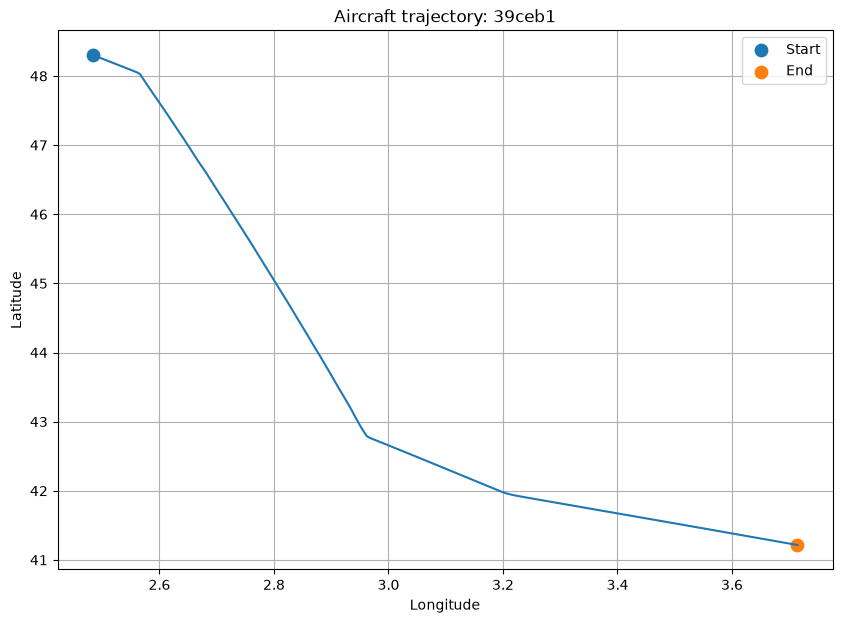

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.plot(
    flight["lon"],
    flight["lat"],
)

plt.scatter(
    flight["lon"].iloc[0],
    flight["lat"].iloc[0],
    s=80,
    label="Start",
)

plt.scatter(
    flight["lon"].iloc[-1],
    flight["lat"].iloc[-1],
    s=80,
    label="End",
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Aircraft trajectory: {icao24}")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
import numpy as np

flight["heading_sin"] = np.sin(
    np.deg2rad(flight["heading"])
)

flight["heading_cos"] = np.cos(
    np.deg2rad(flight["heading"])
)

display(
    flight[
        [
            "datetime",
            "heading",
            "heading_sin",
            "heading_cos",
        ]
    ].head(10)
)

,datetime,heading,heading_sin,heading_cos
2,2022-05-30 07:00:00+00:00,168.370632,0.201580,-0.979472
3019,2022-05-30 07:00:10+00:00,168.285769,0.203031,-0.979172
6416,2022-05-30 07:00:20+00:00,168.201845,0.204465,-0.978874
10645,2022-05-30 07:00:30+00:00,168.320422,0.202438,-0.979295
14976,2022-05-30 07:00:40+00:00,168.378834,0.201440,-0.979501
18762,2022-05-30 07:00:50+00:00,168.354026,0.201864,-0.979414
22531,2022-05-30 07:01:00+00:00,168.468207,0.199912,-0.979814
28087,2022-05-30 07:01:10+00:00,168.442986,0.200343,-0.979726
30897,2022-05-30 07:01:20+00:00,168.362355,0.201721,-0.979443
35589,2022-05-30 07:01:30+00:00,168.310631,0.202606,-0.979260


In [19]:
HISTORY_POINTS = 30   # 5 минут истории
FUTURE_POINTS = 30    # 5 минут прогноза
STRIDE_POINTS = 6     # новое окно каждые 60 секунд

FEATURES = [
    "lat",
    "lon",
    "velocity",
    "vertrate",
    "baroaltitude",
    "heading_sin",
    "heading_cos",
]

TARGETS = [
    "lat",
    "lon",
    "baroaltitude",
]

print("История:", HISTORY_POINTS, "точек")
print("Прогноз:", FUTURE_POINTS, "точек")
print("Шаг окна:", STRIDE_POINTS, "точек")
print("Признаки:", FEATURES)
print("Цели:", TARGETS)

История: 30 точек
Прогноз: 30 точек
Шаг окна: 6 точек
Признаки: ['lat', 'lon', 'velocity', 'vertrate', 'baroaltitude', 'heading_sin', 'heading_cos']
Цели: ['lat', 'lon', 'baroaltitude']


In [21]:
history = flight.iloc[:HISTORY_POINTS].copy()
future = flight.iloc[HISTORY_POINTS:HISTORY_POINTS + FUTURE_POINTS].copy()

base_lat = history["lat"].iloc[-1]
base_lon = history["lon"].iloc[-1]
base_alt = history["baroaltitude"].iloc[-1]

X = history[FEATURES].to_numpy()

y = future[TARGETS].to_numpy().copy()

y[:, 0] -= base_lat
y[:, 1] -= base_lon
y[:, 2] -= base_alt

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30, 7)
y shape: (30, 3)


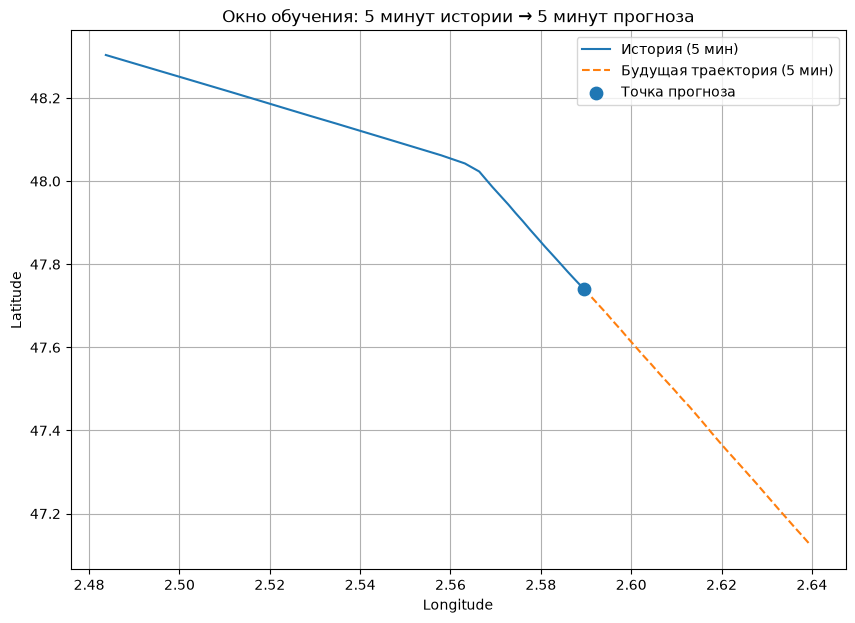

In [22]:
import matplotlib.pyplot as plt

history_plot = history.copy()
future_plot = future.copy()

plt.figure(figsize=(10, 7))

plt.plot(
    history_plot["lon"],
    history_plot["lat"],
    label="История (5 мин)",
)

plt.plot(
    future_plot["lon"],
    future_plot["lat"],
    "--",
    label="Будущая траектория (5 мин)",
)

plt.scatter(
    history_plot["lon"].iloc[-1],
    history_plot["lat"].iloc[-1],
    s=80,
    label="Точка прогноза",
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Окно обучения: 5 минут истории → 5 минут прогноза")
plt.legend()
plt.grid(True)

plt.show()

In [23]:
def make_windows(
    segment_df,
    history_points=HISTORY_POINTS,
    future_points=FUTURE_POINTS,
    stride_points=STRIDE_POINTS,
):
    segment_df = segment_df.sort_values("datetime").reset_index(drop=True).copy()

    # Кодируем циклический признак heading
    segment_df["heading_sin"] = np.sin(
        np.deg2rad(segment_df["heading"])
    )
    segment_df["heading_cos"] = np.cos(
        np.deg2rad(segment_df["heading"])
    )

    total_points = history_points + future_points

    X_windows = []
    y_windows = []
    metadata = []

    for start in range(
        0,
        len(segment_df) - total_points + 1,
        stride_points,
    ):
        history = segment_df.iloc[
            start : start + history_points
        ]

        future = segment_df.iloc[
            start + history_points :
            start + total_points
        ]

        # Для фиксированного шага 10 секунд
        if not (
            history["dt_seconds"].iloc[1:] == 10
        ).all():
            continue

        if not (
            future["dt_seconds"].iloc[1:] == 10
        ).all():
            continue

        X = history[FEATURES].to_numpy()

        base_lat = history["lat"].iloc[-1]
        base_lon = history["lon"].iloc[-1]
        base_alt = history["baroaltitude"].iloc[-1]

        y = future[TARGETS].to_numpy().copy()

        y[:, 0] -= base_lat
        y[:, 1] -= base_lon
        y[:, 2] -= base_alt

        X_windows.append(X)
        y_windows.append(y)

        metadata.append(
            {
                "icao24": segment_df["icao24"].iloc[0],
                "start_time": history["datetime"].iloc[0],
                "forecast_start": future["datetime"].iloc[0],
            }
        )

    return (
        np.array(X_windows),
        np.array(y_windows),
        pd.DataFrame(metadata),
    )

In [18]:
X_sample, y_sample, meta_sample = make_windows(flight)

print(f"Количество окон: {len(X_sample):,}")
print(f"X shape: {X_sample.shape}")
print(f"y shape: {y_sample.shape}")

display(meta_sample.head())

Количество окон: 51
X shape: (51, 30, 7)
y shape: (51, 30, 3)


,icao24,start_time,forecast_start
0,39ceb1,2022-05-30 07:00:00+00:00,2022-05-30 07:05:00+00:00
1,39ceb1,2022-05-30 07:01:00+00:00,2022-05-30 07:06:00+00:00
2,39ceb1,2022-05-30 07:02:00+00:00,2022-05-30 07:07:00+00:00
3,39ceb1,2022-05-30 07:03:00+00:00,2022-05-30 07:08:00+00:00
4,39ceb1,2022-05-30 07:04:00+00:00,2022-05-30 07:09:00+00:00


In [19]:
all_X = []
all_y = []
all_meta = []

for (icao24, segment_id), segment_df in trajectory.groupby(
    ["icao24", "segment"]
):
    if len(segment_df) < HISTORY_POINTS + FUTURE_POINTS:
        continue

    X_part, y_part, meta_part = make_windows(segment_df)

    if len(X_part) == 0:
        continue

    meta_part["segment"] = segment_id

    all_X.append(X_part)
    all_y.append(y_part)
    all_meta.append(meta_part)

X_file = np.concatenate(all_X)
y_file = np.concatenate(all_y)
meta_file = pd.concat(all_meta, ignore_index=True)

print(f"Окон: {len(X_file):,}")
print(f"X shape: {X_file.shape}")
print(f"y shape: {y_file.shape}")
print(f"Самолётов: {meta_file['icao24'].nunique():,}")

Окон: 166,261
X shape: (166261, 30, 7)
y shape: (166261, 30, 3)
Самолётов: 6,264


In [24]:
def build_windows_from_file(file):
    df = pd.read_csv(file)

    df["datetime"] = pd.to_datetime(
        df["time"],
        unit="s",
        utc=True,
    )

    trajectory = (
        df.dropna(
            subset=[
                "lat",
                "lon",
                "velocity",
                "heading",
                "vertrate",
                "baroaltitude",
            ]
        )
        .loc[lambda x: x["onground"] == False]
        .sort_values(["icao24", "datetime"])
        .copy()
    )

    trajectory["dt_seconds"] = (
        trajectory.groupby("icao24")["datetime"]
        .diff()
        .dt.total_seconds()
    )

    trajectory["segment"] = (
        trajectory["dt_seconds"]
        .gt(20)
        .groupby(trajectory["icao24"])
        .cumsum()
    )

    X_windows = []
    y_windows = []
    metadata = []

    total_points = HISTORY_POINTS + FUTURE_POINTS

    for (icao24, segment_id), segment_df in trajectory.groupby(
        ["icao24", "segment"]
    ):
        if len(segment_df) < total_points:
            continue

        segment_df = segment_df.reset_index(drop=True)

        # heading -> sin/cos
        segment_df["heading_sin"] = np.sin(
            np.deg2rad(segment_df["heading"])
        )
        segment_df["heading_cos"] = np.cos(
            np.deg2rad(segment_df["heading"])
        )

        for start in range(
            0,
            len(segment_df) - total_points + 1,
            STRIDE_POINTS,
        ):
            window = segment_df.iloc[
                start : start + total_points
            ]

            # Оставляем только окна с шагом ровно 10 секунд
            if not (
                window["dt_seconds"].iloc[1:] == 10
            ).all():
                continue

            history = window.iloc[:HISTORY_POINTS]
            future = window.iloc[HISTORY_POINTS:]

            X = history[FEATURES].to_numpy()

            base_lat = history["lat"].iloc[-1]
            base_lon = history["lon"].iloc[-1]
            base_alt = history["baroaltitude"].iloc[-1]

            y = future[TARGETS].to_numpy().copy()

            y[:, 0] -= base_lat
            y[:, 1] -= base_lon
            y[:, 2] -= base_alt

            X_windows.append(X)
            y_windows.append(y)

            metadata.append(
                {
                    "icao24": icao24,
                    "segment": segment_id,
                    "start_time": history["datetime"].iloc[0],
                    "forecast_start": future["datetime"].iloc[0],
                }
            )

    if not X_windows:
        return None, None, None

    return (
        np.asarray(X_windows, dtype=np.float32),
        np.asarray(y_windows, dtype=np.float32),
        pd.DataFrame(metadata),
    )

In [6]:
X_all = []
y_all = []
meta_all = []

for i, file in enumerate(files, 1):
    print(f"[{i}/{len(files)}] Обработка {file.name}...")

    X_part, y_part, meta_part = build_windows_from_file(file)

    if X_part is None:
        print("  Подходящих окон нет.")
        continue

    X_all.append(X_part)
    y_all.append(y_part)
    meta_all.append(meta_part)

    print(f"  Окон: {len(X_part):,}")

X_all = np.concatenate(X_all)
y_all = np.concatenate(y_all)
meta_all = pd.concat(meta_all, ignore_index=True)

print("\nИТОГО")
print(f"X: {X_all.shape}")
print(f"y: {y_all.shape}")
print(f"Окон: {len(X_all):,}")
print(f"Самолётов: {meta_all['icao24'].nunique():,}")

[1/4] Обработка states_2022-05-30-07.csv...
  Окон: 166,248
[2/4] Обработка states_2022-05-30-09.csv...
  Окон: 182,462
[3/4] Обработка states_2022-05-30-19.csv...
  Окон: 320,334
[4/4] Обработка states_2022-06-27-09.csv...
  Окон: 192,512

ИТОГО
X: (861556, 30, 7)
y: (861556, 30, 3)
Окон: 861,556
Самолётов: 21,049


In [26]:
from sklearn.model_selection import GroupShuffleSplit

groups = meta_all["icao24"].to_numpy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42,
)

train_idx, test_idx = next(
    splitter.split(X_all, y_all, groups=groups)
)

X_train = X_all[train_idx]
y_train = y_all[train_idx]

X_test = X_all[test_idx]
y_test = y_all[test_idx]

groups_train = groups[train_idx]
groups_test = groups[test_idx]

print("TRAIN")
print("X:", X_train.shape)
print("y:", y_train.shape)
print("Самолётов:", len(np.unique(groups_train)))

print("\nTEST")
print("X:", X_test.shape)
print("y:", y_test.shape)
print("Самолётов:", len(np.unique(groups_test)))

TRAIN
X: (688398, 30, 7)
y: (688398, 30, 3)
Самолётов: 16839

TEST
X: (173158, 30, 7)
y: (173158, 30, 3)
Самолётов: 4210


In [28]:
splitter_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.125,
    random_state=42,
)

train_idx, val_idx = next(
    splitter_val.split(
        X_train,
        y_train,
        groups=groups_train,
    )
)

X_train, X_val = X_train[train_idx], X_train[val_idx]
y_train, y_val = y_train[train_idx], y_train[val_idx]

groups_train, groups_val = (
    groups_train[train_idx],
    groups_train[val_idx],
)

print("TRAIN")
print("X:", X_train.shape)
print("y:", y_train.shape)
print("Самолётов:", len(np.unique(groups_train)))

print("\nVALIDATION")
print("X:", X_val.shape)
print("y:", y_val.shape)
print("Самолётов:", len(np.unique(groups_val)))

print("\nTEST")
print("X:", X_test.shape)
print("y:", y_test.shape)
print("Самолётов:", len(np.unique(groups_test)))

TRAIN
X: (531140, 30, 7)
y: (531140, 30, 3)
Самолётов: 12892

VALIDATION
X: (74391, 30, 7)
y: (74391, 30, 3)
Самолётов: 1842

TEST
X: (173158, 30, 7)
y: (173158, 30, 3)
Самолётов: 4210


In [29]:
EARTH_RADIUS_M = 6_371_000.0
DT = 10.0


def constant_velocity_baseline(X):
    last = X[:, -1, :]

    lat = last[:, 0]
    velocity = last[:, 2]
    vertrate = last[:, 3]

    heading = np.arctan2(
        last[:, 5],
        last[:, 6],
    )

    steps = np.arange(
        1,
        FUTURE_POINTS + 1,
        dtype=np.float32,
    )

    distance = velocity[:, None] * DT * steps[None, :]

    lat_rad = np.deg2rad(lat)

    delta_lat = (
        distance * np.cos(heading[:, None])
        / EARTH_RADIUS_M
    )

    delta_lon = (
        distance * np.sin(heading[:, None])
        / (
            EARTH_RADIUS_M
            * np.cos(lat_rad[:, None])
        )
    )

    delta_lat = np.rad2deg(delta_lat)
    delta_lon = np.rad2deg(delta_lon)

    delta_altitude = (
        vertrate[:, None]
        * DT
        * steps[None, :]
    )

    return np.stack(
        [
            delta_lat,
            delta_lon,
            delta_altitude,
        ],
        axis=2,
    )

In [30]:
def evaluate_baseline(X, y):
    prediction = constant_velocity_baseline(X)

    lat_error = prediction[:, :, 0] - y[:, :, 0]
    lon_error = prediction[:, :, 1] - y[:, :, 1]
    alt_error = prediction[:, :, 2] - y[:, :, 2]

    lat_scale = 111_320.0

    mean_lat = X[:, -1, 0]

    lat_error_m = lat_error * lat_scale

    lon_error_m = (
        lon_error
        * lat_scale
        * np.cos(np.deg2rad(mean_lat[:, None]))
    )

    horizontal_error_m = np.sqrt(
        lat_error_m**2 + lon_error_m**2
    )

    altitude_error_m = np.abs(alt_error)

    horizons = {
        "1 мин": 5,
        "3 мин": 15,
        "5 мин": 30,
    }

    results = []

    for name, step in horizons.items():
        results.append(
            {
                "Горизонт": name,
                "MAE position, м": horizontal_error_m[:, step - 1].mean(),
                "MAE altitude, м": altitude_error_m[:, step - 1].mean(),
            }
        )

    return pd.DataFrame(results)


baseline_val = evaluate_baseline(X_val, y_val)

display(baseline_val)

,Горизонт,"MAE position, м","MAE altitude, м"
0,1 мин,929.342834,51.525757
1,3 мин,2974.293457,185.993164
2,5 мин,7925.940918,452.077759


In [31]:
baseline_val = evaluate_baseline(X_val, y_val)

display(baseline_val)

,Горизонт,"MAE position, м","MAE altitude, м"
0,1 мин,929.342834,51.525757
1,3 мин,2974.293457,185.993164
2,5 мин,7925.940918,452.077759


In [32]:
import torch
from torch import nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.14.0+cu130
Device: cpu


In [36]:
from sklearn.preprocessing import StandardScaler

X_train_2d = X_train.reshape(len(X_train), -1)
X_val_2d = X_val.reshape(len(X_val), -1)

y_train_2d = y_train.reshape(len(y_train), -1)
y_val_2d = y_val.reshape(len(y_val), -1)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train_2d)
X_val_scaled = x_scaler.transform(X_val_2d)

y_train_scaled = y_scaler.fit_transform(y_train_2d)
y_val_scaled = y_scaler.transform(y_val_2d)

print("X train:", X_train_scaled.shape)
print("X val:", X_val_scaled.shape)
print("y train:", y_train_scaled.shape)
print("y val:", y_val_scaled.shape)

X train: (531140, 210)
X val: (74391, 210)
y train: (531140, 90)
y val: (74391, 90)


In [37]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1024,
    shuffle=False,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 1038
Validation batches: 73


In [38]:
class TrajectoryMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(30 * 7, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 30 * 3),
        )

    def forward(self, x):
        return self.network(x)


model = TrajectoryMLP().to(device)

print(model)

TrajectoryMLP(
  (network): Sequential(
    (0): Linear(in_features=210, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=90, bias=True)
  )
)


In [39]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        prediction = model(X_batch)
        loss = criterion(prediction, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(X_batch)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            prediction = model(X_batch)
            loss = criterion(prediction, y_batch)

            val_loss += loss.item() * len(X_batch)

    val_loss /= len(val_loader.dataset)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"train loss: {train_loss:.5f} | "
        f"val loss: {val_loss:.5f}"
    )

Epoch 1/5 | train loss: 0.36249 | val loss: 0.20479
Epoch 2/5 | train loss: 0.34648 | val loss: 0.19795
Epoch 3/5 | train loss: 0.33598 | val loss: 0.18109
Epoch 4/5 | train loss: 0.33041 | val loss: 0.18102
Epoch 5/5 | train loss: 0.32735 | val loss: 0.18822


In [40]:
model.eval()

predictions = []

with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        prediction = model(X_batch)
        predictions.append(prediction.cpu().numpy())

y_pred_scaled = np.concatenate(predictions, axis=0)

# Возвращаем исходный масштаб
y_pred = y_scaler.inverse_transform(y_pred_scaled)

y_pred = y_pred.reshape(-1, FUTURE_POINTS, 3)
y_val_original = y_val

print("Prediction shape:", y_pred.shape)

Prediction shape: (74391, 30, 3)


In [41]:
def evaluate_predictions(y_true, y_pred, X_reference):
    lat_error = y_pred[:, :, 0] - y_true[:, :, 0]
    lon_error = y_pred[:, :, 1] - y_true[:, :, 1]
    alt_error = y_pred[:, :, 2] - y_true[:, :, 2]

    lat_scale = 111_320.0
    mean_lat = X_reference[:, -1, 0]

    lat_error_m = lat_error * lat_scale
    lon_error_m = (
        lon_error
        * lat_scale
        * np.cos(np.deg2rad(mean_lat[:, None]))
    )

    horizontal_error_m = np.sqrt(
        lat_error_m**2 + lon_error_m**2
    )

    altitude_error_m = np.abs(alt_error)

    horizons = {
        "1 мин": 5,
        "3 мин": 15,
        "5 мин": 30,
    }

    results = []

    for name, step in horizons.items():
        results.append({
            "Горизонт": name,
            "MAE position, м": horizontal_error_m[:, step - 1].mean(),
            "MAE altitude, м": altitude_error_m[:, step - 1].mean(),
        })

    return pd.DataFrame(results)


mlp_results = evaluate_predictions(
    y_val_original,
    y_pred,
    X_val,
)

mlp_results

,Горизонт,"MAE position, м","MAE altitude, м"
0,1 мин,1443.586182,54.281384
1,3 мин,3902.645020,156.988403
2,5 мин,8918.683594,339.838928


In [44]:
comparison = pd.DataFrame({
    "Горизонт": ["1 мин", "3 мин", "5 мин"],
    "Baseline position, м": baseline_errors["MAE position, м"],
    "MLP position, м": mlp_errors["MAE position, м"],
    "Baseline altitude, м": baseline_errors["MAE altitude, м"],
    "MLP altitude, м": mlp_errors["MAE altitude, м"],
})

comparison

,Горизонт,"Baseline position, м","MLP position, м","Baseline altitude, м","MLP altitude, м"
0,1 мин,929.342834,1443.586182,51.525757,54.281384
1,3 мин,2974.293457,3902.645020,185.993164,156.988403
2,5 мин,7925.940918,8918.683594,452.077759,339.838928


In [45]:
X_train_lstm = torch.tensor(X_train, dtype=torch.float32)
y_train_lstm = torch.tensor(y_train, dtype=torch.float32)

X_val_lstm = torch.tensor(X_val, dtype=torch.float32)
y_val_lstm = torch.tensor(y_val, dtype=torch.float32)

train_dataset_lstm = TensorDataset(
    X_train_lstm,
    y_train_lstm,
)

val_dataset_lstm = TensorDataset(
    X_val_lstm,
    y_val_lstm,
)

train_loader_lstm = DataLoader(
    train_dataset_lstm,
    batch_size=512,
    shuffle=True,
)

val_loader_lstm = DataLoader(
    val_dataset_lstm,
    batch_size=1024,
    shuffle=False,
)

print("X:", X_train_lstm.shape)
print("y:", y_train_lstm.shape)

X: torch.Size([531140, 30, 7])
y: torch.Size([531140, 30, 3])


In [46]:
class TrajectoryLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.1,
        )

        self.head = nn.Linear(hidden_size, 30 * 3)

    def forward(self, x):
        output, _ = self.lstm(x)

        # Используем последнее состояние истории
        last_hidden = output[:, -1, :]

        prediction = self.head(last_hidden)

        return prediction.reshape(-1, 30, 3)


lstm_model = TrajectoryLSTM().to(device)

print(lstm_model)

TrajectoryLSTM(
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.1)
  (head): Linear(in_features=64, out_features=90, bias=True)
)
